In [2]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from PIL import Image

torch.hub.set_dir("../model_cache/torch/hub")
import sys
sys.path.append("/mnt/home/mizrahiulysse/ElasticDino")
from elasticdino.model.elasticdino import ElasticDino
from elasticdino.training.util import debug_features

def get_edino():
    edino = ElasticDino.from_pretrained("/mnt/home/mizrahiulysse/pixelvit-32-L.pth", "elasticdino-32-L", dino_repo="/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main")
    edino.eval()
    edino.requires_grad_ = False
    return edino

# edino = get_edino().cuda()
edino = get_edino().cuda()

{'deformed_features': tensor([[[[-0.4932, -0.4931, -0.4931,  ..., -0.4717, -0.4768, -0.4799],
          [-0.4974, -0.4971, -0.4965,  ..., -0.4645, -0.4679, -0.4704],
          [-0.5014, -0.5009, -0.4999,  ..., -0.4524, -0.4533, -0.4542],
          ...,
          [-0.5503, -0.5487, -0.5464,  ..., -0.3496, -0.3490, -0.3483],
          [-0.5362, -0.5344, -0.5318,  ..., -0.3494, -0.3492, -0.3491],
          [-0.5246, -0.5226, -0.5192,  ..., -0.3493, -0.3494, -0.3495]],

         [[-0.5630, -0.5637, -0.5652,  ..., -0.4235, -0.4173, -0.4133],
          [-0.5658, -0.5670, -0.5694,  ..., -0.4388, -0.4341, -0.4303],
          [-0.5690, -0.5705, -0.5737,  ..., -0.4620, -0.4592, -0.4569],
          ...,
          [-0.3769, -0.3856, -0.4008,  ..., -0.7127, -0.7129, -0.7131],
          [-0.3940, -0.4025, -0.4170,  ..., -0.7050, -0.7049, -0.7047],
          [-0.4082, -0.4164, -0.4310,  ..., -0.7008, -0.7005, -0.7002]],

         [[ 0.0809,  0.0808,  0.0806,  ...,  0.1235,  0.1258,  0.1273],
        

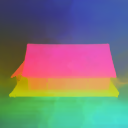

tensor(-0.4932, device='cuda:0', grad_fn=<SelectBackward0>)


In [3]:
img = Image.open("/mnt/home/mizrahiulysse/datasets/universal_renders/universal_renders/00/2009000_000/fix_el_20_az_0_alpha.png")
img = img.convert("RGB").resize((256, 256))
img_tensors = torchvision.transforms.functional.pil_to_tensor(img).unsqueeze(0).cuda() / 255.0
r = edino(img_tensors, n_hidden_layers=1)
print(r)
h = r["hidden_layers"]
print(len(h))
from IPython.display import display
display(debug_features(r["deformed_features"][0], []))
print(r["deformed_features"][0][0][0][0])
h = [hh for i, hh in enumerate(h) if i % 3 ==2]
for hh in h:
    print(hh[0][0][0][0])
    display(debug_features(hh[0], []))
    